# AR7W Density Structure

In [7]:
import numpy as np
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import cm
import matplotlib.colors as mcolors
import pandas as pd
import gsw

In [2]:
# open dataset
# ar7w_ds = xr.open_dataset("/Users/mzahn/data/Labrador_AR7W/igor_ds/AR7W_netcdf/igor_ar7w.nc") # local
ar7w_ds = xr.open_dataset("~/efs-mount-point/mzahn/data/ar7w/igor_ar7w.nc") # s3

In [10]:
# Open bathymetry
# bathy = xr.open_dataset('/Users/mzahn/data/GEBCO/GEBCO_2023.nc')
bathy = xr.open_dataset("~/efs-mount-point/mzahn/data/bathy/gebco_2021_sub_ice_n90.0_s30.0_w-120.0_e30.0.nc")
bathy_greenland = bathy.elevation.sel(lon=slice(-65, -35),lat=slice(50, 70)).isel(lon=slice(None, None, 10),lat=slice(None, None, 10))

In [3]:
# ar7w_1998 = ar7w_ds.sel(time=slice('1998-06','1998-10'))
ar7w_1998 = ar7w_ds.sel(time='1998')
ar7w_1999 = ar7w_ds.sel(time='1999')
# ar7w_2000 = ar7w_ds.sel(time='2000')
ar7w_2019 = ar7w_ds.sel(time='2019')
ar7w_2023 = ar7w_ds.sel(time='2023')

## identify start and end points of AR7W transect

In [20]:
print(ar7w_2019.latitude.min().values)
print(ar7w_2019.longitude.min().values)

print(ar7w_2019.latitude.max().values)
print(ar7w_2019.longitude.max().values)

53.5617
-55.6603
60.6203
-48.1667


In [33]:
# # AR7W reference end-points  (Labrador SW → Greenland NE)
LAT_SW, LON_SW = 53.56, -55.66   # Labrador shelf end
LAT_NE, LON_NE = 60.62, -48.17   # Greenland shelf end

/tmp/ipykernel_10378/2797001719.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('turbo', 12)


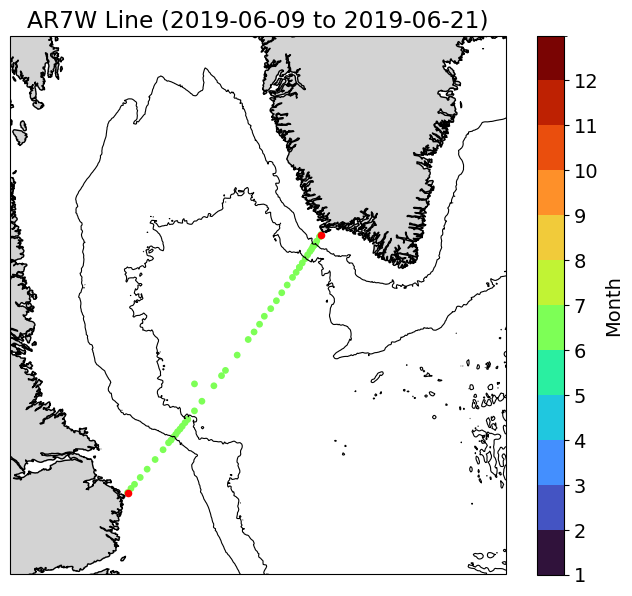

In [36]:
plt.rcParams['font.size'] = 14

# --- extract month from time ---
months = ar7w_2019.time.dt.month.values  # assumes xarray datetime

# --- colormap setup (1–12 months) ---
cmap = cm.get_cmap('turbo', 12)
norm = mcolors.BoundaryNorm(boundaries=range(1,14), ncolors=12)

# Plot map
fig = plt.figure(figsize=(8,7))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))
ax.set_extent([-60, -40, 52, 65], crs=ccrs.PlateCarree())
# ax.set_extent([-50, -46, 59, 61], crs=ccrs.PlateCarree())

sc = ax.scatter(
    ar7w_2019.longitude,
    ar7w_2019.latitude,
    c=months,
    cmap=cmap,
    norm=norm,
    s=15,
    transform=ccrs.PlateCarree()
)

ax.scatter(LON_SW, LAT_SW, c='r', s=20, transform=ccrs.PlateCarree())
ax.scatter(LON_NE, LAT_NE, c='r', s=20, transform=ccrs.PlateCarree())

# Coastlines and land
ax.coastlines()
ax.add_feature(cfeature.LAND, color="lightgray")

# Bathymetry contours
bathy_levels = [-3000, -1000]
cs = ax.contour(
    bathy_greenland.lon,
    bathy_greenland.lat,
    bathy_greenland,
    levels=bathy_levels,
    colors="black",
    linewidths=0.8,
    linestyles="solid",
    transform=ccrs.PlateCarree()
)

# --- colorbar ---
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.05)
cbar.set_label('Month')
cbar.set_ticks(range(1,13))

# --- get date range ---
start_time = ar7w_2019.time.min().values
end_time = ar7w_2019.time.max().values

# format nicely (e.g., YYYY-MM-DD)
start_str = np.datetime_as_string(start_time, unit='D')
end_str = np.datetime_as_string(end_time, unit='D')

plt.title(f"AR7W Line ({start_str} to {end_str})")
plt.show()

/tmp/ipykernel_26006/224324408.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('turbo', 12)


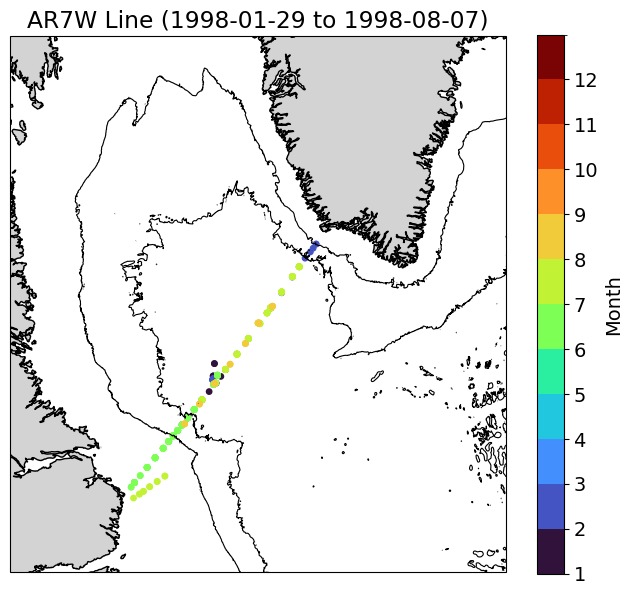

In [102]:
plt.rcParams['font.size'] = 14

# --- extract month from time ---
months = ar7w_1998.time.dt.month.values  # assumes xarray datetime

# --- colormap setup (1–12 months) ---
cmap = cm.get_cmap('turbo', 12)
norm = mcolors.BoundaryNorm(boundaries=range(1,14), ncolors=12)

# Plot map
fig = plt.figure(figsize=(8,7))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))
ax.set_extent([-60, -40, 52, 65], crs=ccrs.PlateCarree())

sc = ax.scatter(
    ar7w_1998.longitude,
    ar7w_1998.latitude,
    c=months,
    cmap=cmap,
    norm=norm,
    s=15,
    transform=ccrs.PlateCarree()
)

# Coastlines and land
ax.coastlines()
ax.add_feature(cfeature.LAND, color="lightgray")

# Bathymetry contours
bathy_levels = [-3000, -1000]
cs = ax.contour(
    bathy_greenland.lon,
    bathy_greenland.lat,
    bathy_greenland,
    levels=bathy_levels,
    colors="black",
    linewidths=0.8,
    linestyles="solid",
    transform=ccrs.PlateCarree()
)

# --- colorbar ---
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.05)
cbar.set_label('Month')
cbar.set_ticks(range(1,13))

# --- get date range ---
start_time = ar7w_1998.time.min().values
end_time = ar7w_1998.time.max().values

# format nicely (e.g., YYYY-MM-DD)
start_str = np.datetime_as_string(start_time, unit='D')
end_str = np.datetime_as_string(end_time, unit='D')

plt.title(f"AR7W Line ({start_str} to {end_str})")
plt.show()

/tmp/ipykernel_26006/2362731910.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('turbo', 12)


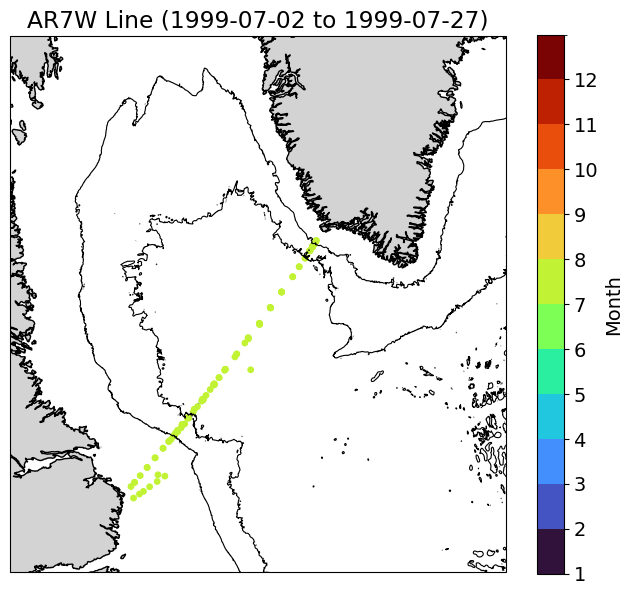

In [100]:
plt.rcParams['font.size'] = 14

# --- extract month from time ---
months = ar7w_1999.time.dt.month.values  # assumes xarray datetime

# --- colormap setup (1–12 months) ---
cmap = cm.get_cmap('turbo', 12)
norm = mcolors.BoundaryNorm(boundaries=range(1,14), ncolors=12)

# Plot map
fig = plt.figure(figsize=(8,7))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))
ax.set_extent([-60, -40, 52, 65], crs=ccrs.PlateCarree())

sc = ax.scatter(
    ar7w_1999.longitude,
    ar7w_1999.latitude,
    c=months,
    cmap=cmap,
    norm=norm,
    s=15,
    transform=ccrs.PlateCarree()
)

# Coastlines and land
ax.coastlines()
ax.add_feature(cfeature.LAND, color="lightgray")

# Bathymetry contours
bathy_levels = [-3000, -1000]
cs = ax.contour(
    bathy_greenland.lon,
    bathy_greenland.lat,
    bathy_greenland,
    levels=bathy_levels,
    colors="black",
    linewidths=0.8,
    linestyles="solid",
    transform=ccrs.PlateCarree()
)

# --- colorbar ---
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.05)
cbar.set_label('Month')
cbar.set_ticks(range(1,13))

# --- get date range ---
start_time = ar7w_1999.time.min().values
end_time = ar7w_1999.time.max().values

# format nicely (e.g., YYYY-MM-DD)
start_str = np.datetime_as_string(start_time, unit='D')
end_str = np.datetime_as_string(end_time, unit='D')

plt.title(f"AR7W Line ({start_str} to {end_str})")
plt.show()

/tmp/ipykernel_26006/3289428225.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('turbo', 12)


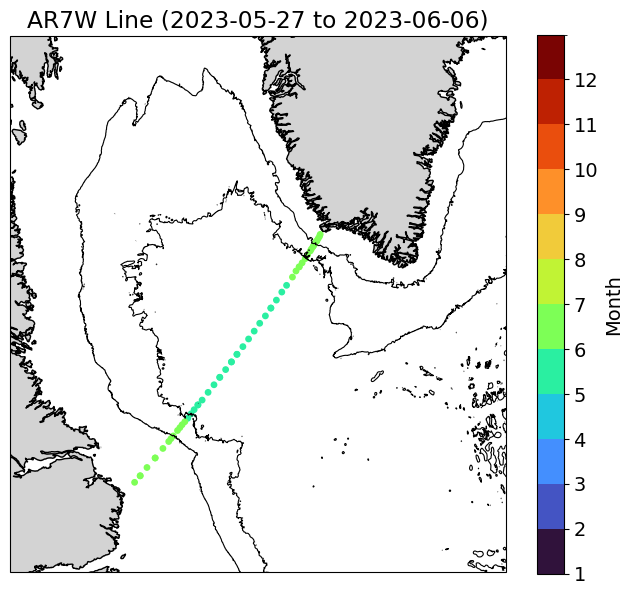

In [94]:
plt.rcParams['font.size'] = 14

# --- extract month from time ---
months = ar7w_2023.time.dt.month.values  # assumes xarray datetime

# --- colormap setup (1–12 months) ---
cmap = cm.get_cmap('turbo', 12)
norm = mcolors.BoundaryNorm(boundaries=range(1,14), ncolors=12)

# Plot map
fig = plt.figure(figsize=(8,7))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))
ax.set_extent([-60, -40, 52, 65], crs=ccrs.PlateCarree())

sc = ax.scatter(
    ar7w_2023.longitude,
    ar7w_2023.latitude,
    c=months,
    cmap=cmap,
    norm=norm,
    s=15,
    transform=ccrs.PlateCarree()
)

# Coastlines and land
ax.coastlines()
ax.add_feature(cfeature.LAND, color="lightgray")

# Bathymetry contours
bathy_levels = [-3000, -1000]
cs = ax.contour(
    bathy_greenland.lon,
    bathy_greenland.lat,
    bathy_greenland,
    levels=bathy_levels,
    colors="black",
    linewidths=0.8,
    linestyles="solid",
    transform=ccrs.PlateCarree()
)

# --- colorbar ---
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.05)
cbar.set_label('Month')
cbar.set_ticks(range(1,13))

# --- get date range ---
start_time = ar7w_2023.time.min().values
end_time = ar7w_2023.time.max().values

# format nicely (e.g., YYYY-MM-DD)
start_str = np.datetime_as_string(start_time, unit='D')
end_str = np.datetime_as_string(end_time, unit='D')

plt.title(f"AR7W Line ({start_str} to {end_str})")
plt.show()

/tmp/ipykernel_26006/3502213653.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('turbo', 12)
/tmp/ipykernel_26006/3502213653.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar


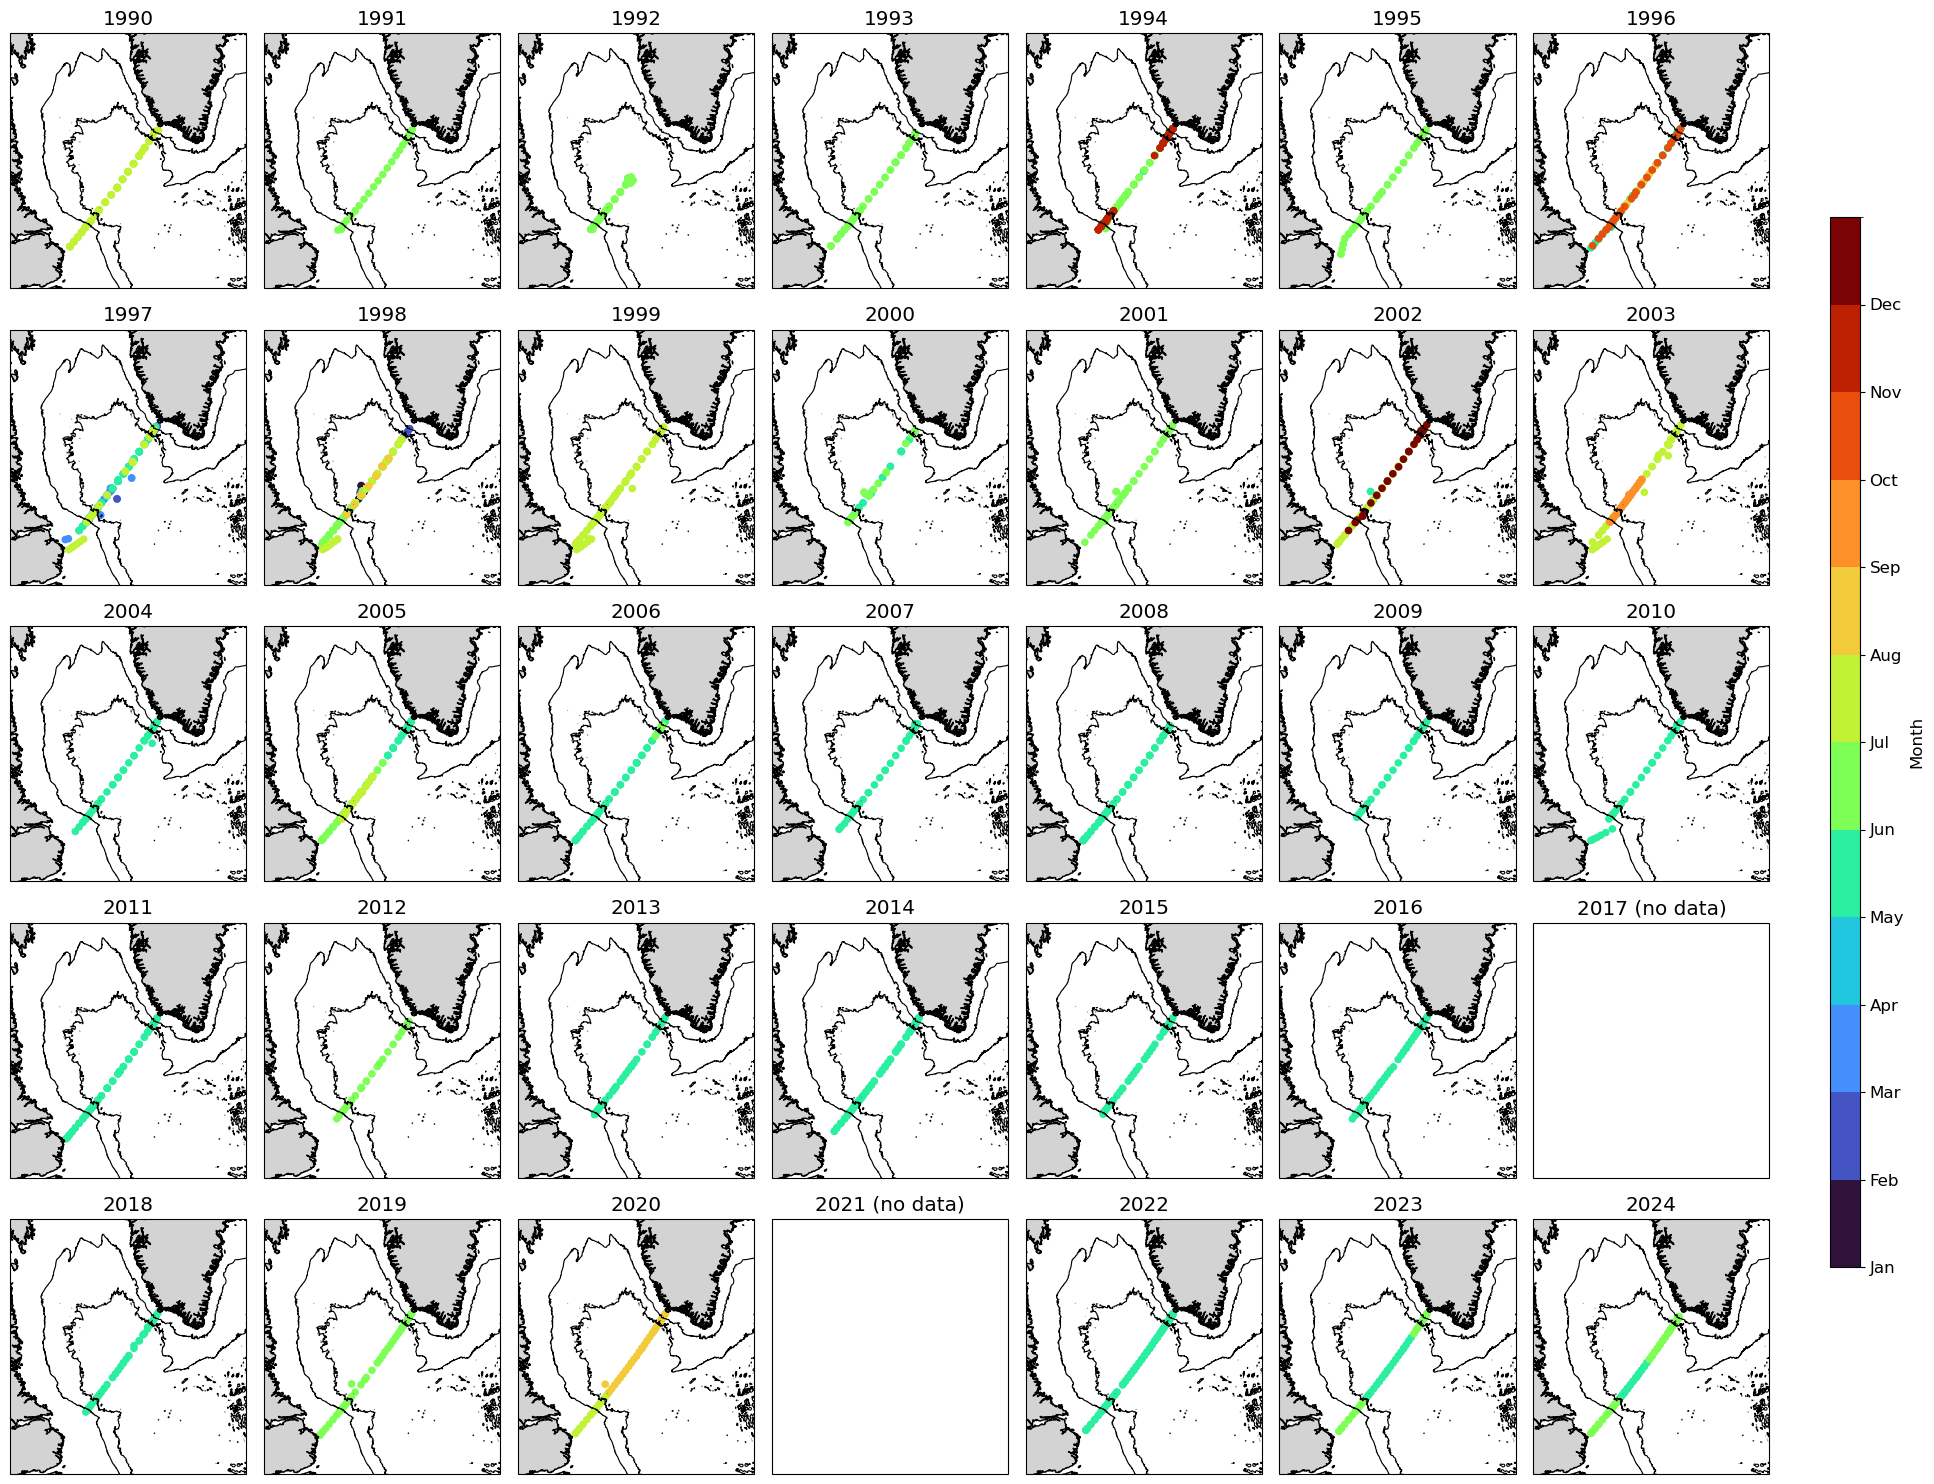

In [86]:
# --- settings ---
plt.rcParams['font.size'] = 12
years = np.arange(1990, 2025)
n_years = len(years)

# Figure layout: 5 rows x 7 columns (35 panels max, adjust as needed)
ncols = 7
nrows = int(np.ceil(n_years / ncols))
fig_width = 20  # wide for PowerPoint
fig_height = 3 * nrows
fig, axes = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height),
                         subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-45)})

# Flatten axes for easy indexing
axes = axes.flatten()

# Colormap setup
cmap = cm.get_cmap('turbo', 12)
norm = mcolors.BoundaryNorm(boundaries=range(1,14), ncolors=12)

# --- loop through years ---
for i, year in enumerate(years):
    ax = axes[i]
    ax.set_extent([-60, -40, 52, 65], crs=ccrs.PlateCarree())

    # extract data for this year
    ds_year = ar7w_ds.sel(time=str(year))
    if len(ds_year.time) == 0:
        ax.set_title(f"{year} (no data)")
        continue

    months = ds_year.time.dt.month.values

    sc = ax.scatter(
        ds_year.longitude,
        ds_year.latitude,
        c=months,
        cmap=cmap,
        norm=norm,
        s=20,
        transform=ccrs.PlateCarree()
    )

    ax.coastlines()
    ax.add_feature(cfeature.LAND, color="lightgray")

    # bathymetry contours
    bathy_levels = [-3000, -1000]
    ax.contour(
        bathy_greenland.lon,
        bathy_greenland.lat,
        bathy_greenland,
        levels=bathy_levels,
        colors="black",
        linewidths=0.8,
        linestyles="solid",
        transform=ccrs.PlateCarree()
    )

    ax.set_title(str(year))

# Turn off any empty axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

# --- shared colorbar ---
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
cbar = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax)
cbar.set_label("Month")
cbar.set_ticks(range(1,13))
cbar.set_ticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar
plt.show()

In [167]:
# order based on distance
ar7w_2023_sort = ar7w_2023.sortby('distance').swap_dims({'time':'distance'})

In [169]:
# convert latitude and longitude coords to data variables to preserve them
ar7w_2023_sort = ar7w_2023_sort.reset_coords(['latitude', 'longitude'])

In [171]:
# mask any profiles where both temp and salinity are all NaN over pressure
bad = (ar7w_2023_sort['temperature'].isnull().all(dim='pressure') &
       ar7w_2023_sort['salinity'].isnull().all(dim='pressure'))

# keep only good profiles
ar7w_2023_filter = ar7w_2023_sort.sel(distance=~bad)

In [173]:
# take average across profiles that have the same distance
ar7w_2023_avg = ar7w_2023_filter.groupby('distance').mean(dim='distance')

In [177]:
ds = ar7w_2023_avg
bathy = bathy_greenland

distance = ds['distance']
lat = ds['latitude']
lon = ds['longitude']

temp = ds['temperature']
salt = ds['salinity']
sigma = ds['sigma']
pressure = ds['pressure']

In [179]:
SA = gsw.SA_from_SP(salt, pressure, lon, lat)
CT = gsw.CT_from_t(SA, temp, pressure)
rho = gsw.rho(SA, CT, pressure)

In [181]:
bathy_interp = bathy.interp(
    lon=("points", lon.values),
    lat=("points", lat.values)
)

bathy_depth = -bathy_interp.values

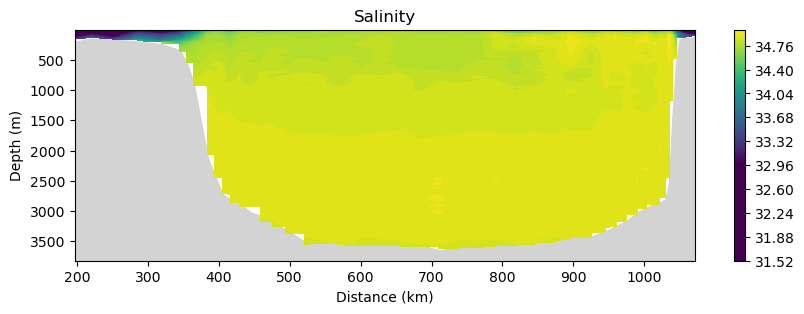

In [183]:
plt.figure(figsize=(10,3))

plt.fill_between(distance, bathy_depth, pressure.max(),
                 color='lightgray', zorder=1)

cf = plt.contourf(distance, pressure, salt.T,
                  levels=100,vmin=33,vmax=35,
                  cmap='viridis')

plt.gca().invert_yaxis()
plt.xlabel("Distance (km)")
plt.ylabel("Depth (m)")
plt.title("Salinity")

plt.colorbar(cf)
plt.show()

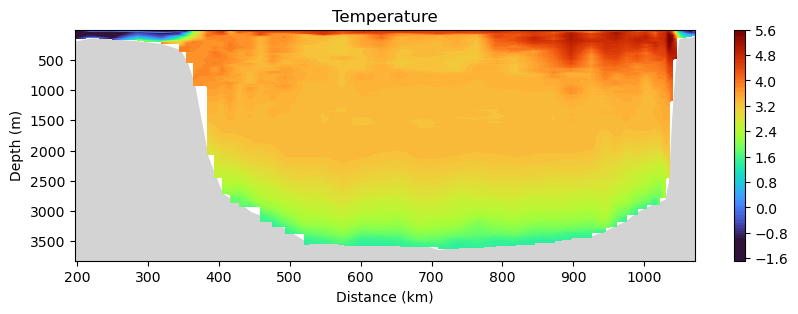

In [195]:
plt.figure(figsize=(10,3))

plt.fill_between(distance, bathy_depth, pressure.max(),
                 color='lightgray', zorder=1)

cf = plt.contourf(distance, pressure, temp.T,
                  levels=100,vmin=-1,vmax=5.5,
                  cmap='turbo')

plt.gca().invert_yaxis()
plt.xlabel("Distance (km)")
plt.ylabel("Depth (m)")
plt.title("Temperature")
# plt.xlim(800,850)

plt.colorbar(cf)
plt.show()

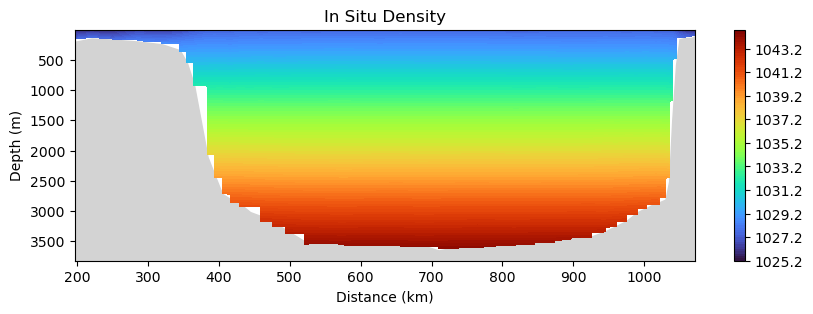

In [191]:
plt.figure(figsize=(10,3))

plt.fill_between(distance, bathy_depth, pressure.max(),
                 color='lightgray', zorder=1)

cf = plt.contourf(distance, pressure, rho.T,
                  levels=100,
                  cmap='turbo')

plt.gca().invert_yaxis()
plt.xlabel("Distance (km)")
plt.ylabel("Depth (m)")
plt.title("In Situ Density")

plt.colorbar(cf)
plt.show()